<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>


# 🧭 **Support Vector Machine (SVM) para Auditores Bancarios**

Este notebook explica y aplica **Support Vector Machine (SVM)** en contextos de auditoría bancaria: scoring de crédito, fraude, AML, priorización de alertas y revisión de modelos supervisados.

El notebook mantiene la estructura del tema anterior: explicación del algoritmo, puntos críticos de auditoría, implementación completa en Python, validación, calibración, estabilidad, fairness y 10 ejercicios finales con nuevos datos.


## 1. FUNDAMENTOS TEÓRICOS

SVM es un algoritmo supervisado usado principalmente para clasificación. Su objetivo no es estimar directamente una probabilidad, sino construir una **frontera de decisión** que separe clases maximizando el margen entre ellas.

En banca puede utilizarse para default crediticio, fraude, AML, clasificación de expedientes y alertas de riesgo.


### 1.1 ¿Qué es un SVM?

Un SVM busca el hiperplano que mejor separa dos clases. Los puntos más cercanos a la frontera son los **support vectors** y determinan la posición de la frontera.

Intuición: no basta con separar clientes buenos y malos; el modelo intenta dejar la mayor distancia posible respecto a los casos más difíciles.


### 1.2 Hiperplano y margen

Un hiperplano lineal puede expresarse como `w^T x + b = 0`. El SVM lineal maximiza el margen entre clases.

En datos bancarios reales casi nunca existe separación perfecta, por lo que se usa **soft margin SVM**, que permite algunos errores controlados.


### 1.3 Soft margin y parámetro C

El parámetro **C** controla cuánto penaliza el modelo los errores:

| C | Efecto | Riesgo |
|---|---|---|
| Bajo | Más regularización y margen más amplio | Infraajuste |
| Alto | Penaliza mucho los errores | Sobreajuste |

Auditoría debe revisar que C se haya elegido con validación y no por selección oportunista.


### 1.4 Kernel trick

Los kernels permiten separar clases no lineales sin transformar explícitamente los datos.

| Kernel | Uso | Riesgo |
|---|---|---|
| Linear | Alta dimensionalidad, más defendible | Puede no captar no linealidad |
| RBF | No linealidad general | Menor interpretabilidad |
| Polynomial | Interacciones | Sobreajuste |
| Sigmoid | Uso menos habitual | Difícil de justificar |


### 1.5 Gamma en kernel RBF

En RBF, **gamma** controla la influencia de cada observación.

| Gamma | Efecto | Riesgo |
|---|---|---|
| Bajo | Frontera suave | Infraajuste |
| Alto | Frontera flexible | Sobreajuste |

La combinación C alto + gamma alto es especialmente delicada en auditoría.


### 1.6 Escalado obligatorio

SVM depende de distancias. Si una variable está en euros y otra en porcentaje, la escala puede dominar la frontera.

Por tanto, se debe usar `StandardScaler`, `RobustScaler` u otra estrategia documentada, siempre ajustada solo en train mediante pipeline.


### 1.7 SVM y probabilidades

SVM produce distancia a la frontera, no probabilidades nativas. En `sklearn`, `SVC(probability=True)` aplica calibración interna, pero debe validarse.

Si el score se usa como PD, pérdida esperada, pricing o provisiones, la calibración es un control obligatorio.


### 1.8 Aspectos críticos para auditores bancarios

Auditoría debe revisar: objetivo del modelo, definición temporal del target, leakage, escalado, kernel, hiperparámetros, desbalanceo, calibración, explicabilidad, estabilidad temporal, fairness y trazabilidad documental.


### 1.9 Métricas clave

| Métrica | Uso |
|---|---|
| Accuracy | Puede ser engañosa con desbalanceo |
| Precision | Control de falsos positivos |
| Recall | Captura de eventos reales |
| F1 | Balance precision-recall |
| AUC-ROC | Ranking global |
| PR-AUC | Clase minoritaria |
| Brier Score | Calidad probabilística |
| PSI | Estabilidad poblacional |


## 2. CONFIGURACIÓN Y LIBRERÍAS


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, brier_score_loss
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3. FUNCIONES AUXILIARES DE AUDITORÍA


In [2]:
def evaluar_clasificacion(nombre_modelo, y_true, y_pred, y_score=None):
    resultados = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    if y_score is not None:
        resultados["auc_roc"] = roc_auc_score(y_true, y_score)
        resultados["pr_auc"] = average_precision_score(y_true, y_score)
        resultados["brier_score"] = brier_score_loss(y_true, y_score)
    return pd.DataFrame([resultados])

def matriz_confusion_df(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Predicho 0", "Predicho 1"])

def calcular_psi(expected, actual, buckets=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    bins = np.unique(np.quantile(expected, np.linspace(0, 1, buckets + 1)))
    if len(bins) <= 2:
        bins = np.linspace(min(expected.min(), actual.min()), max(expected.max(), actual.max()), buckets + 1)
    bins[0], bins[-1] = -np.inf, np.inf
    e = pd.cut(expected, bins=bins, include_lowest=True).value_counts(sort=False)
    a = pd.cut(actual, bins=bins, include_lowest=True).value_counts(sort=False)
    ep = (e / e.sum()).replace(0, 0.0001)
    ap = (a / a.sum()).replace(0, 0.0001)
    psi = (ap - ep) * np.log(ap / ep)
    detalle = pd.DataFrame({"bin": e.index.astype(str), "expected_perc": ep.values, "actual_perc": ap.values, "psi": psi.values})
    return psi.sum(), detalle

def evaluar_por_segmento(df, y_true_col, y_pred_col, segmento_col):
    filas = []
    for segmento, data in df.groupby(segmento_col):
        filas.append({
            "segmento_riesgo_cliente": segmento,
            "n": len(data),
            "tasa_real_evento": data[y_true_col].mean(),
            "tasa_predicha_evento": data[y_pred_col].mean(),
            "precision": precision_score(data[y_true_col], data[y_pred_col], zero_division=0),
            "recall": recall_score(data[y_true_col], data[y_pred_col], zero_division=0),
            "f1": f1_score(data[y_true_col], data[y_pred_col], zero_division=0)
        })
    return pd.DataFrame(filas)


## 4. LECTURA / GENERACIÓN DE DATOS BANCARIOS

Generaremos un dataset sintético ejecutable sin ficheros externos. La variable objetivo es `riesgo_auditoria`.


In [3]:
# Carga de los datos reales generados en el script introductorio
# El CSV debe estar en la misma carpeta que este notebook.

from pathlib import Path

ruta_csv = Path("../../data/auditoria_bancaria_desbalanceada.csv")
if not ruta_csv.exists():
    ruta_csv = Path("/mnt/data/auditoria_bancaria_desbalanceada.csv")

df = pd.read_csv(ruta_csv)

# Para que SVM sea manejable en ordenadores locales, trabajamos con una muestra reproducible
# manteniendo la proporción de la clase minoritaria.
if len(df) > 6000:
    df = (
        df.groupby("riesgo_auditoria", group_keys=False)
          .apply(lambda x: x.sample(frac=6000/len(df), random_state=RANDOM_STATE))
          .sample(frac=1, random_state=RANDOM_STATE)
          .reset_index(drop=True)
    )

print(df.shape)
df.head()

(6000, 17)


,id_operacion,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,14061,1047.78,21051.44,19,6428.19,17.0,783.0,0.115,1,29.0,0.080,app,empresa,bajo,transferencia,medio,0
1,439,528.56,13671.79,19,2019.33,88.0,843.0,0.603,0,32.0,0.087,oficina,empresa,bajo,tarjeta,bajo,0
2,6938,757.60,22749.64,15,10428.15,57.0,670.0,0.174,0,69.0,0.072,web,particular,medio,transferencia,bajo,0
3,14723,191.47,339.67,20,2681.35,58.0,664.0,0.456,0,23.0,0.124,oficina,particular,bajo,tarjeta,bajo,0
4,13862,1796.84,6448.59,15,28452.94,103.0,827.0,0.292,3,27.0,0.090,cajero,particular,medio,prestamo,medio,0


## 5. ANÁLISIS EXPLORATORIO DE DATOS


In [4]:
df.shape

(6000, 17)

In [ ]:
df.info()

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_operacion,6000.0,NaN,NaN,NaN,7466.304,4311.876568,1.0,3721.75,7513.0,11134.75,14999.0
importe_operacion,6000.0,NaN,NaN,NaN,1465.34617,2419.224599,8.98,334.6225,738.39,1664.0275,47597.28
saldo_medio_cliente,6000.0,NaN,NaN,NaN,9738.377348,12254.816737,122.35,3011.325,5998.255,11806.785,245519.52
num_operaciones_30d,6000.0,NaN,NaN,NaN,17.907,4.239695,5.0,15.0,18.0,21.0,35.0
importe_total_30d,6000.0,NaN,NaN,NaN,11628.57607,22650.179197,0.0,2151.0775,5654.01,12325.5325,552633.46
antiguedad_cliente_meses,6000.0,NaN,NaN,NaN,62.319167,33.715918,3.0,38.0,56.0,80.0,292.0
score_crediticio,6000.0,NaN,NaN,NaN,679.544167,84.623696,356.0,622.0,679.0,738.0,900.0
ratio_ingresos_deuda,6000.0,NaN,NaN,NaN,0.285288,0.15083,0.008,0.168,0.265,0.382,0.866
num_alertas_previas,6000.0,NaN,NaN,NaN,0.451,0.66358,0.0,0.0,0.0,1.0,4.0
dias_desde_ultima_revision,6000.0,NaN,NaN,NaN,106.641,104.526661,1.0,32.0,75.0,149.0,897.0


In [6]:
df["riesgo_auditoria"].value_counts(normalize=True).rename("proporcion")


riesgo_auditoria
0    0.936833
1    0.063167
Name: proporcion, dtype: float64

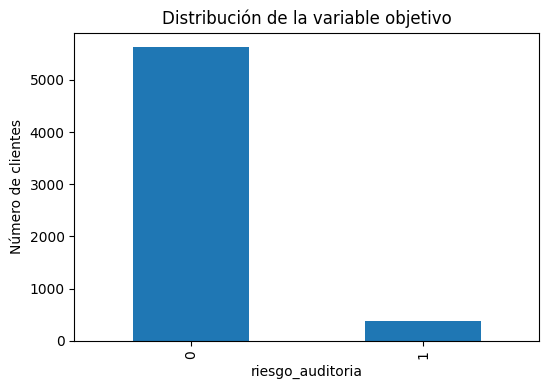

In [7]:
plt.figure(figsize=(6,4))
df["riesgo_auditoria"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("riesgo_auditoria")
plt.ylabel("Número de clientes")
plt.show()


In [8]:
df.groupby("segmento_riesgo_cliente")["riesgo_auditoria"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
segmento_riesgo_cliente,,
alto,464,0.245690
medio,1615,0.090402
bajo,3921,0.030349


## 6. PREPROCESAMIENTO Y PARTICIÓN TRAIN / TEST

Usamos `ColumnTransformer` y `Pipeline` para evitar leakage. En SVM el escalado no es opcional.


In [9]:
target = "riesgo_auditoria"

# En auditoría no usamos identificadores técnicos como predictores.
id_cols = [col for col in ["id_operacion"] if col in df.columns]

X = df.drop(columns=[target] + id_cols)
y = df[target].astype(int)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)
print("Train/Test:", X_train.shape, X_test.shape)
print("Tasa de riesgo en train/test:", round(y_train.mean(), 4), round(y_test.mean(), 4))

Variables numéricas: ['importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales']
Variables categóricas: ['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente']
Train/Test: (4200, 15) (1800, 15)
Tasa de riesgo en train/test: 0.0631 0.0633


## 7. MODELO BASE: SVM LINEAL

Entrenamos un modelo con kernel `linear`. Auditoría debe revisar complejidad, rendimiento, estabilidad y explicación.


In [10]:
svm_linear = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="linear", C=1.0, class_weight="balanced", probability=True, random_state=RANDOM_STATE))
])
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
y_score_linear = svm_linear.predict_proba(X_test)[:, 1]
evaluar_clasificacion("SVM lineal", y_test, y_pred_linear, y_score_linear)


,modelo,accuracy,precision,recall,f1,auc_roc,pr_auc,brier_score
0,SVM lineal,0.936111,0.497561,0.894737,0.639498,0.946822,0.853657,0.020311


In [11]:
matriz_confusion_df(y_test, y_pred_linear)

,Predicho 0,Predicho 1
Real 0,1583,103
Real 1,12,102


## 8. MODELO SVM CON KERNEL RBF

Entrenamos un modelo con kernel `rbf`. Auditoría debe revisar complejidad, rendimiento, estabilidad y explicación.


In [12]:
svm_rbf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=True, random_state=RANDOM_STATE))
])
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
y_score_rbf = svm_rbf.predict_proba(X_test)[:, 1]
evaluar_clasificacion("SVM RBF", y_test, y_pred_rbf, y_score_rbf)

,modelo,accuracy,precision,recall,f1,auc_roc,pr_auc,brier_score
0,SVM RBF,0.958889,0.633333,0.833333,0.719697,0.947348,0.830048,0.022311


In [13]:
matriz_confusion_df(y_test, y_pred_rbf)

,Predicho 0,Predicho 1
Real 0,1631,55
Real 1,19,95


## 9. MODELO SVM POLINÓMICO

Entrenamos un modelo con kernel `poly`. Auditoría debe revisar complejidad, rendimiento, estabilidad y explicación.


In [14]:
svm_poly = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="poly", degree=2, C=1.0, gamma="scale", class_weight="balanced", probability=True, random_state=RANDOM_STATE))
])
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
y_score_poly = svm_poly.predict_proba(X_test)[:, 1]
evaluar_clasificacion("SVM polinómico grado 2", y_test, y_pred_poly, y_score_poly)


,modelo,accuracy,precision,recall,f1,auc_roc,pr_auc,brier_score
0,SVM polinómico grado 2,0.947222,0.551913,0.885965,0.680135,0.93053,0.79469,0.023722


In [15]:
matriz_confusion_df(y_test, y_pred_poly)

,Predicho 0,Predicho 1
Real 0,1604,82
Real 1,13,101


### 9.1 Interpretación del SVM lineal

El SVM lineal permite revisar coeficientes, aunque no son odds ratios y están afectados por el escalado y por el one-hot encoding.


In [16]:
feature_names = svm_linear.named_steps["preprocessor"].get_feature_names_out()
coef = svm_linear.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({"variable": feature_names, "coeficiente": coef, "abs_coef": np.abs(coef)}).sort_values("abs_coef", ascending=False)
coef_df.head(15)

,variable,coeficiente,abs_coef
19,cat__pais_riesgo_alto,1.553379,1.553379
27,cat__segmento_riesgo_cliente_alto,1.524619,1.524619
28,cat__segmento_riesgo_cliente_bajo,-1.400895,1.400895
20,cat__pais_riesgo_bajo,-1.295110,1.295110
7,num__num_alertas_previas,0.849332,0.849332
5,num__score_crediticio,-0.748548,0.748548
4,num__antiguedad_cliente_meses,-0.718194,0.718194
10,cat__canal_operacion_api,0.685719,0.685719
26,cat__producto_transferencia,0.680653,0.680653
9,num__porcentaje_operaciones_internacionales,0.658622,0.658622


## 10. COMPARACIÓN DE MODELOS


In [17]:
comparacion = pd.concat([
    evaluar_clasificacion("SVM lineal", y_test, y_pred_linear, y_score_linear),
    evaluar_clasificacion("SVM RBF", y_test, y_pred_rbf, y_score_rbf),
    evaluar_clasificacion("SVM polinómico", y_test, y_pred_poly, y_score_poly)
], ignore_index=True)
comparacion.sort_values("auc_roc", ascending=False)

,modelo,accuracy,precision,recall,f1,auc_roc,pr_auc,brier_score
1,SVM RBF,0.958889,0.633333,0.833333,0.719697,0.947348,0.830048,0.022311
0,SVM lineal,0.936111,0.497561,0.894737,0.639498,0.946822,0.853657,0.020311
2,SVM polinómico,0.947222,0.551913,0.885965,0.680135,0.930530,0.794690,0.023722


<Figure size 600x500 with 0 Axes>

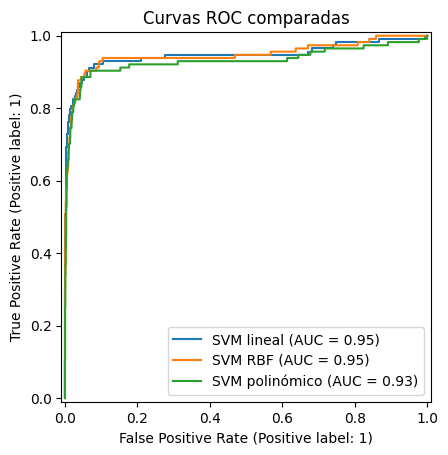

In [18]:
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_score_linear, name="SVM lineal")
RocCurveDisplay.from_predictions(y_test, y_score_rbf, name="SVM RBF", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_score_poly, name="SVM polinómico", ax=plt.gca())
plt.title("Curvas ROC comparadas")
plt.show()

<Figure size 600x500 with 0 Axes>

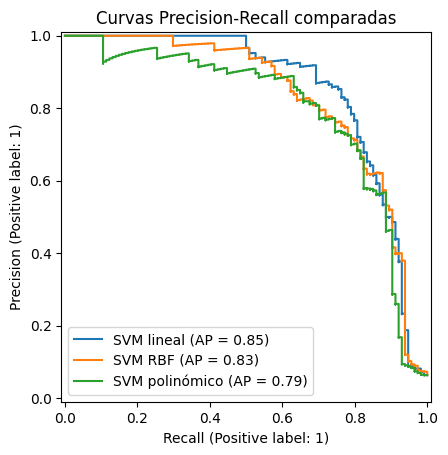

In [19]:
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test, y_score_linear, name="SVM lineal")
PrecisionRecallDisplay.from_predictions(y_test, y_score_rbf, name="SVM RBF", ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, y_score_poly, name="SVM polinómico", ax=plt.gca())
plt.title("Curvas Precision-Recall comparadas")
plt.show()

## 11. MATRIZ DE CONFUSIÓN Y UMBRALES DE DECISIÓN

El umbral 0.5 no debe aceptarse por defecto. En banca debe alinearse con coste de falsos positivos, falsos negativos y capacidad operativa.


In [20]:
umbrales = np.arange(0.05, 0.95, 0.05)
filas = []
for u in umbrales:
    pred_u = (y_score_rbf >= u).astype(int)
    filas.append({"umbral": round(u,2), "precision": precision_score(y_test,pred_u,zero_division=0),
                  "recall": recall_score(y_test,pred_u,zero_division=0), "f1": f1_score(y_test,pred_u,zero_division=0),
                  "tasa_alertas": pred_u.mean()})
umbrales_df = pd.DataFrame(filas)
umbrales_df

,umbral,precision,recall,f1,tasa_alertas
0,0.05,0.361486,0.938596,0.521951,0.164444
1,0.10,0.459821,0.903509,0.609467,0.124444
2,0.15,0.537234,0.885965,0.668874,0.104444
3,0.20,0.581395,0.877193,0.699301,0.095556
4,0.25,0.620915,0.833333,0.711610,0.085000
5,0.30,0.678832,0.815789,0.741036,0.076111
6,0.35,0.750000,0.763158,0.756522,0.064444
7,0.40,0.772727,0.745614,0.758929,0.061111
8,0.45,0.796117,0.719298,0.755760,0.057222
9,0.50,0.808081,0.701754,0.751174,0.055000


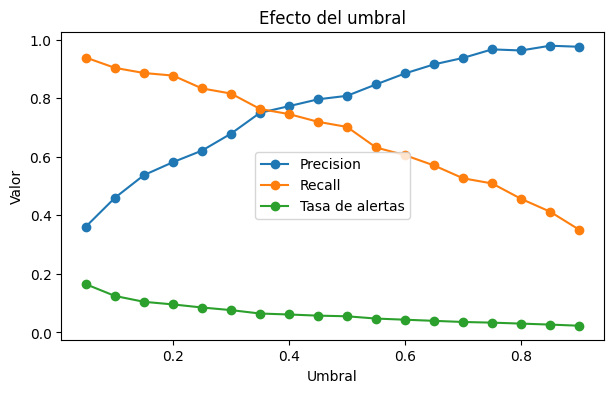

In [21]:
plt.figure(figsize=(7,4))
plt.plot(umbrales_df["umbral"], umbrales_df["precision"], marker="o", label="Precision")
plt.plot(umbrales_df["umbral"], umbrales_df["recall"], marker="o", label="Recall")
plt.plot(umbrales_df["umbral"], umbrales_df["tasa_alertas"], marker="o", label="Tasa de alertas")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.title("Efecto del umbral")
plt.legend()
plt.show()

## 12. EXPLICABILIDAD E IMPORTANCIA DE VARIABLES

Para SVM no lineal usamos permutation importance como aproximación global. No implica causalidad, pero ayuda a detectar variables críticas.


In [22]:
perm = permutation_importance(svm_rbf, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({"variable": X_test.columns, "importancia_media": perm.importances_mean, "importancia_std": perm.importances_std}).sort_values("importancia_media", ascending=False)
perm_df

,variable,importancia_media,importancia_std
12,pais_riesgo,0.061540,0.002481
14,segmento_riesgo_cliente,0.045448,0.005569
5,score_crediticio,0.041082,0.003807
9,porcentaje_operaciones_internacionales,0.031517,0.002615
7,num_alertas_previas,0.028357,0.003002
4,antiguedad_cliente_meses,0.021071,0.005842
13,producto,0.006457,0.003202
3,importe_total_30d,0.003891,0.005680
10,canal_operacion,0.003256,0.001566
1,saldo_medio_cliente,0.003013,0.001319


<Figure size 800x400 with 0 Axes>

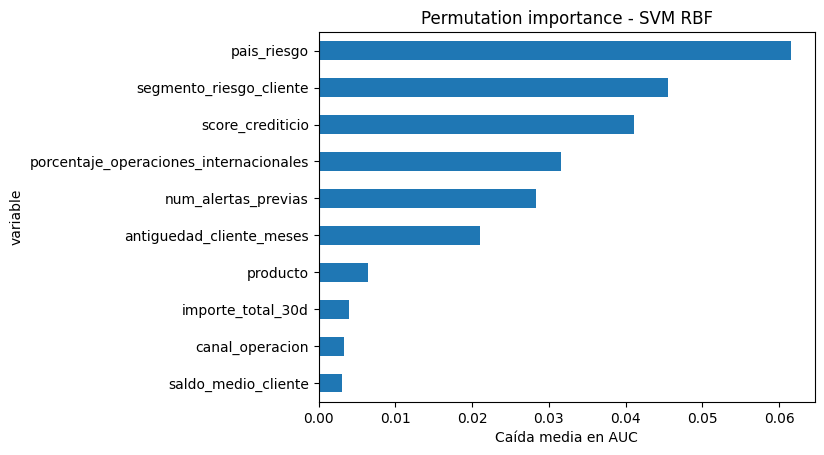

In [23]:
plt.figure(figsize=(8,4))
perm_df.head(10).sort_values("importancia_media").plot(x="variable", y="importancia_media", kind="barh", legend=False)
plt.title("Permutation importance - SVM RBF")
plt.xlabel("Caída media en AUC")
plt.show()

## 13. VALIDACIÓN CRUZADA Y RIESGO DE SOBREAJUSTE


In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"auc_roc":"roc_auc", "pr_auc":"average_precision", "f1":"f1", "recall":"recall", "precision":"precision"}
cv_results = cross_validate(svm_rbf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
pd.DataFrame(cv_results).mean().to_frame("media")

,media
fit_time,0.464791
score_time,0.068390
test_auc_roc,0.969269
train_auc_roc,0.997912
test_pr_auc,0.827268
train_pr_auc,0.989098
test_f1,0.733883
train_f1,0.897007
test_recall,0.822642
train_recall,0.989623


### 13.1 Señales de sobreajuste

AUC train muy superior a test, gamma alto, C alto, alta variabilidad entre folds, muchas variables con pocos eventos o caída temporal fuerte.


## 14. CALIBRACIÓN DE PROBABILIDADES


In [25]:
base_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=False, random_state=RANDOM_STATE))
])
calibrated_svm = CalibratedClassifierCV(base_svm, method="sigmoid", cv=3)
calibrated_svm.fit(X_train, y_train)
y_score_cal = calibrated_svm.predict_proba(X_test)[:, 1]
y_pred_cal = (y_score_cal >= 0.5).astype(int)
evaluar_clasificacion("SVM RBF calibrado", y_test, y_pred_cal, y_score_cal)


,modelo,accuracy,precision,recall,f1,auc_roc,pr_auc,brier_score
0,SVM RBF calibrado,0.967778,0.858974,0.587719,0.697917,0.948388,0.828737,0.023566


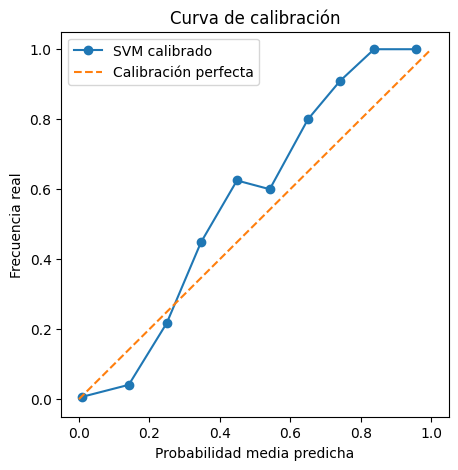

In [26]:
prob_true, prob_pred = calibration_curve(y_test, y_score_cal, n_bins=10)
plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker="o", label="SVM calibrado")
plt.plot([0,1], [0,1], linestyle="--", label="Calibración perfecta")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Frecuencia real")
plt.title("Curva de calibración")
plt.legend()
plt.show()


## 15. ESTABILIDAD TEMPORAL Y PSI


In [27]:
df_futuro = df.copy()

# Simulamos un pequeño cambio de población: operaciones algo mayores, más alertas previas
# y más operaciones internacionales.
df_futuro["importe_operacion"] = (df_futuro["importe_operacion"] * np.random.normal(1.08, 0.10, len(df_futuro))).clip(lower=0)
df_futuro["num_alertas_previas"] = (df_futuro["num_alertas_previas"] + np.random.poisson(0.3, len(df_futuro))).clip(0, 20)
df_futuro["porcentaje_operaciones_internacionales"] = (df_futuro["porcentaje_operaciones_internacionales"] + np.random.normal(0.03, 0.04, len(df_futuro))).clip(0, 1)

X_futuro = df_futuro.drop(columns=[target] + id_cols)
score_futuro = calibrated_svm.predict_proba(X_futuro.loc[X_test.index])[:, 1]
psi_total, psi_detalle = calcular_psi(y_score_cal, score_futuro)
psi_total

np.float64(0.06195804585235447)

In [28]:
psi_detalle


,bin,expected_perc,actual_perc,psi
0,"(-inf, 0.000188]",0.1,0.074444,0.007542
1,"(0.000188, 0.000422]",0.1,0.077778,0.005585
2,"(0.000422, 0.000796]",0.1,0.078333,0.005291
3,"(0.000796, 0.00154]",0.1,0.090556,0.000937
4,"(0.00154, 0.00322]",0.1,0.093889,0.000385
5,"(0.00322, 0.00707]",0.1,0.098889,0.000012
6,"(0.00707, 0.0153]",0.1,0.084444,0.002630
7,"(0.0153, 0.041]",0.1,0.112222,0.001409
8,"(0.041, 0.178]",0.1,0.123889,0.005117
9,"(0.178, inf]",0.1,0.165556,0.033049


### 15.1 Guía PSI

| PSI | Interpretación |
|---|---|
| < 0.10 | Bajo |
| 0.10 - 0.25 | Moderado |
| > 0.25 | Relevante |


## 16. FAIRNESS Y ANÁLISIS POR SEGMENTOS


In [29]:
df_eval = X_test.copy()
df_eval["y_true"] = y_test.values
df_eval["y_pred"] = y_pred_cal
df_eval["score"] = y_score_cal
evaluar_por_segmento(df_eval, "y_true", "y_pred", "segmento_riesgo_cliente")

,segmento_riesgo_cliente,n,tasa_real_evento,tasa_predicha_evento,precision,recall,f1
0,alto,146,0.239726,0.164384,0.958333,0.657143,0.779661
1,bajo,1199,0.032527,0.020851,0.880000,0.564103,0.687500
2,medio,455,0.087912,0.063736,0.758621,0.550000,0.637681


In [32]:
evaluar_por_segmento(df_eval, "y_true", "y_pred", "canal_operacion")


,segmento_riesgo_cliente,n,tasa_real_evento,tasa_predicha_evento,precision,recall,f1
0,api,83,0.156627,0.060241,1.000000,0.384615,0.555556
1,app,723,0.051176,0.041494,0.666667,0.540541,0.597015
2,cajero,238,0.092437,0.071429,0.941176,0.727273,0.820513
3,oficina,222,0.040541,0.036036,1.000000,0.888889,0.941176
4,web,534,0.061798,0.033708,1.000000,0.545455,0.705882


## 17. HYPERPARAMETER TUNING CONTROLADO


In [33]:
param_grid = {"model__C": [0.1, 1, 5], "model__gamma": ["scale", 0.01, 0.1]}
svm_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE))
])
grid = GridSearchCV(svm_tuning, param_grid=param_grid, scoring="roc_auc", cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
grid.best_params_, grid.best_score_

({'model__C': 1, 'model__gamma': 0.01}, np.float64(0.9714718871863702))

In [34]:
best_svm = grid.best_estimator_
y_score_best = best_svm.predict_proba(X_test)[:, 1]
y_pred_best = best_svm.predict(X_test)
evaluar_clasificacion("SVM RBF tuned", y_test, y_pred_best, y_score_best)

,modelo,accuracy,precision,recall,f1,auc_roc,pr_auc,brier_score
0,SVM RBF tuned,0.928333,0.467249,0.938596,0.623907,0.95074,0.88333,0.017316


## 18. CASUÍSTICAS BANCARIAS IMPORTANTES

### 18.1 Default crediticio
Riesgos: mala calibración de PD, proxies sensibles, rechazo injustificado, drift macroeconómico y falta de explicabilidad.

### 18.2 Fraude transaccional
Riesgos: fuerte desbalanceo, patrones cambiantes, muchos falsos positivos y carga operativa.

### 18.3 AML
Riesgos: etiquetas ruidosas, baja tasa de positivos, alta sensibilidad regulatoria y necesidad de trazabilidad.

### 18.4 Muchas variables categóricas
Riesgos: alta dimensionalidad tras one-hot, categorías raras y cambios en producción.


# 19. EJERCICIOS PRÁCTICOS PARA RESOLVER

Cada ejercicio incluye nuevos datos. El alumno debe entrenar, evaluar y redactar una conclusión de auditoría.


### 📝 EJERCICIO 1: SVM lineal para scoring de crédito

**Contexto:** El área de Riesgos quiere usar un SVM lineal como challenger de una regresión logística.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 1
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(101)
credit_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=101).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in credit_svm.columns:
        credit_svm[col] = (credit_svm[col] * np.random.normal(1.0, 0.08, len(credit_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in credit_svm.columns:
    credit_svm["num_operaciones_30d"] = (credit_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(credit_svm))).clip(0, None)

if "num_alertas_previas" in credit_svm.columns:
    credit_svm["num_alertas_previas"] = (credit_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(credit_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in credit_svm.columns:
    credit_svm["porcentaje_operaciones_internacionales"] = (credit_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(credit_svm))).clip(0, 1).round(3)

credit_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 1
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 2: Comparativa SVM lineal vs RBF

**Contexto:** Compara rendimiento, complejidad e interpretabilidad.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 2
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(102)
svm_compare = df.sample(n=min(2500, len(df)), replace=True, random_state=102).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in svm_compare.columns:
        svm_compare[col] = (svm_compare[col] * np.random.normal(1.0, 0.08, len(svm_compare))).clip(lower=0).round(2)

if "num_operaciones_30d" in svm_compare.columns:
    svm_compare["num_operaciones_30d"] = (svm_compare["num_operaciones_30d"] + np.random.poisson(0.4, len(svm_compare))).clip(0, None)

if "num_alertas_previas" in svm_compare.columns:
    svm_compare["num_alertas_previas"] = (svm_compare["num_alertas_previas"] + np.random.binomial(1, 0.10, len(svm_compare))).clip(0, None)

if "porcentaje_operaciones_internacionales" in svm_compare.columns:
    svm_compare["porcentaje_operaciones_internacionales"] = (svm_compare["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(svm_compare))).clip(0, 1).round(3)

svm_compare.head()

In [ ]:
# Espacio para resolver el ejercicio 2
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 3: Fraude transaccional desbalanceado

**Contexto:** Revisa métricas adecuadas y umbral operativo.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 3
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(103)
fraud_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=103).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in fraud_svm.columns:
        fraud_svm[col] = (fraud_svm[col] * np.random.normal(1.0, 0.08, len(fraud_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in fraud_svm.columns:
    fraud_svm["num_operaciones_30d"] = (fraud_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(fraud_svm))).clip(0, None)

if "num_alertas_previas" in fraud_svm.columns:
    fraud_svm["num_alertas_previas"] = (fraud_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(fraud_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in fraud_svm.columns:
    fraud_svm["porcentaje_operaciones_internacionales"] = (fraud_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(fraud_svm))).clip(0, 1).round(3)

fraud_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 3
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 4: Impacto del escalado

**Contexto:** Compara SVM sin escalado frente a pipeline con StandardScaler.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 4
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(104)
scaling_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=104).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in scaling_svm.columns:
        scaling_svm[col] = (scaling_svm[col] * np.random.normal(1.0, 0.08, len(scaling_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in scaling_svm.columns:
    scaling_svm["num_operaciones_30d"] = (scaling_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(scaling_svm))).clip(0, None)

if "num_alertas_previas" in scaling_svm.columns:
    scaling_svm["num_alertas_previas"] = (scaling_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(scaling_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in scaling_svm.columns:
    scaling_svm["porcentaje_operaciones_internacionales"] = (scaling_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(scaling_svm))).clip(0, 1).round(3)

scaling_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 4
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 5: Tuning de C y gamma

**Contexto:** Realiza GridSearch y documenta sobreajuste.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 5
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(105)
tuning_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=105).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in tuning_svm.columns:
        tuning_svm[col] = (tuning_svm[col] * np.random.normal(1.0, 0.08, len(tuning_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in tuning_svm.columns:
    tuning_svm["num_operaciones_30d"] = (tuning_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(tuning_svm))).clip(0, None)

if "num_alertas_previas" in tuning_svm.columns:
    tuning_svm["num_alertas_previas"] = (tuning_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(tuning_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in tuning_svm.columns:
    tuning_svm["porcentaje_operaciones_internacionales"] = (tuning_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(tuning_svm))).clip(0, 1).round(3)

tuning_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 5
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 6: Calibración de probabilidades

**Contexto:** Evalúa si las probabilidades son utilizables como PD.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 6
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(106)
calibration_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=106).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in calibration_svm.columns:
        calibration_svm[col] = (calibration_svm[col] * np.random.normal(1.0, 0.08, len(calibration_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in calibration_svm.columns:
    calibration_svm["num_operaciones_30d"] = (calibration_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(calibration_svm))).clip(0, None)

if "num_alertas_previas" in calibration_svm.columns:
    calibration_svm["num_alertas_previas"] = (calibration_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(calibration_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in calibration_svm.columns:
    calibration_svm["porcentaje_operaciones_internacionales"] = (calibration_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(calibration_svm))).clip(0, 1).round(3)

calibration_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 6
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 7: Fairness por canal y segmento

**Contexto:** Analiza diferencias de rendimiento por grupos.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 7
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(107)
fairness_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=107).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in fairness_svm.columns:
        fairness_svm[col] = (fairness_svm[col] * np.random.normal(1.0, 0.08, len(fairness_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in fairness_svm.columns:
    fairness_svm["num_operaciones_30d"] = (fairness_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(fairness_svm))).clip(0, None)

if "num_alertas_previas" in fairness_svm.columns:
    fairness_svm["num_alertas_previas"] = (fairness_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(fairness_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in fairness_svm.columns:
    fairness_svm["porcentaje_operaciones_internacionales"] = (fairness_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(fairness_svm))).clip(0, 1).round(3)

fairness_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 7
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 8: Estabilidad temporal con PSI

**Contexto:** Simula población futura y calcula PSI.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 8
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(108)
psi_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=108).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in psi_svm.columns:
        psi_svm[col] = (psi_svm[col] * np.random.normal(1.0, 0.08, len(psi_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in psi_svm.columns:
    psi_svm["num_operaciones_30d"] = (psi_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(psi_svm))).clip(0, None)

if "num_alertas_previas" in psi_svm.columns:
    psi_svm["num_alertas_previas"] = (psi_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(psi_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in psi_svm.columns:
    psi_svm["porcentaje_operaciones_internacionales"] = (psi_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(psi_svm))).clip(0, 1).round(3)

psi_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 8
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 9: AML con etiquetas ruidosas

**Contexto:** Evalúa limitaciones y trazabilidad.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 9
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(109)
aml_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=109).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in aml_svm.columns:
        aml_svm[col] = (aml_svm[col] * np.random.normal(1.0, 0.08, len(aml_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in aml_svm.columns:
    aml_svm["num_operaciones_30d"] = (aml_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(aml_svm))).clip(0, None)

if "num_alertas_previas" in aml_svm.columns:
    aml_svm["num_alertas_previas"] = (aml_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(aml_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in aml_svm.columns:
    aml_svm["porcentaje_operaciones_internacionales"] = (aml_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(aml_svm))).clip(0, 1).round(3)

aml_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 9
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


### 📝 EJERCICIO 10: Informe integral de auditoría SVM

**Contexto:** Revisa datos, kernel, métricas, calibración, estabilidad, fairness y recomendación final.

**Tareas mínimas:** generar/revisar datos, train/test estratificado, pipeline, entrenamiento SVM, métricas, matriz de confusión, umbral si procede y conclusión de auditoría.


In [ ]:
# Datos nuevos para el ejercicio 10
# Se generan a partir del CSV de auditoría bancaria, con pequeñas perturbaciones
# para simular nuevos lotes de operaciones.

np.random.seed(110)
audit_svm = df.sample(n=min(2500, len(df)), replace=True, random_state=110).reset_index(drop=True).copy()

# Perturbaciones controladas en variables numéricas para crear un nuevo escenario.
for col in ["importe_operacion", "saldo_medio_cliente", "importe_total_30d"]:
    if col in audit_svm.columns:
        audit_svm[col] = (audit_svm[col] * np.random.normal(1.0, 0.08, len(audit_svm))).clip(lower=0).round(2)

if "num_operaciones_30d" in audit_svm.columns:
    audit_svm["num_operaciones_30d"] = (audit_svm["num_operaciones_30d"] + np.random.poisson(0.4, len(audit_svm))).clip(0, None)

if "num_alertas_previas" in audit_svm.columns:
    audit_svm["num_alertas_previas"] = (audit_svm["num_alertas_previas"] + np.random.binomial(1, 0.10, len(audit_svm))).clip(0, None)

if "porcentaje_operaciones_internacionales" in audit_svm.columns:
    audit_svm["porcentaje_operaciones_internacionales"] = (audit_svm["porcentaje_operaciones_internacionales"] + np.random.normal(0, 0.03, len(audit_svm))).clip(0, 1).round(3)

audit_svm.head()

In [ ]:
# Espacio para resolver el ejercicio 10
# Define X/y usando riesgo_auditoria como target, elimina id_operacion si existe, crea train/test, ColumnTransformer, Pipeline con SVC y evalúa el modelo.
# Tu código aquí


## 20. CHECKLIST FINAL PARA AUDITAR UN MODELO SVM EN BANCA

- [ ] Objetivo definido.
- [ ] Target sin leakage.
- [ ] Train/test correcto.
- [ ] Escalado dentro de pipeline.
- [ ] Kernel justificado.
- [ ] C, gamma y degree documentados.
- [ ] Métricas adecuadas al desbalanceo.
- [ ] Matriz de confusión revisada.
- [ ] Umbral operativo justificado.
- [ ] Probabilidades calibradas si se usan como PD.
- [ ] Estabilidad temporal evaluada.
- [ ] Fairness revisado.
- [ ] Explicabilidad suficiente.
- [ ] Comparación con modelos benchmark.
- [ ] Recomendación final documentada.
